# Improved Deep Learning Models for Pneumonia Detection

This notebook implements enhanced versions of the pneumonia detection models:

1. **Improved CNN** - With BatchNormalization, progressive dropout, and L2 regularization
2. **VGG16 Enhanced** - Enhanced classification head + two-phase training (frozen → fine-tuning)
3. **ResNet50 Enhanced** - Enhanced classification head + two-phase training (frozen → fine-tuning)

## Key Improvements

| Model | Improvement |
|-------|-------------|
| CNN | BatchNormalization after each Conv2D/Dense, progressive dropout (0.25→0.5), L2 regularization |
| VGG16 | Enhanced head (512→256→1), two-phase training with fine-tuning of block5 |
| ResNet50 | Enhanced head (512→256→1), two-phase training with fine-tuning of conv5 block |

---
# Setup and Configuration

In [2]:
# Standard library imports
import os
import json
import warnings
from pathlib import Path
from datetime import datetime

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input,
    BatchNormalization, Activation, GlobalAveragePooling2D
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50

# Metrics
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score
)

# Suppress warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

/Users/beatrizfarias/Library/CloudStorage/OneDrive-UniversidadedeAveiro/universidade/5 ano/FAA/Project 2/FAA_Project2/venv/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow version: 2.20.0
GPU available: False


In [3]:
# Directory configuration
DATA_DIR = Path('../data/chest_xray')
PREPROCESSING_DIR = Path('../results/preprocessing')

# Results directories for improved models
RESULTS_BASE = Path('../results/models')
CNN_RESULTS_DIR = RESULTS_BASE / 'cnn_improved'
VGG16_RESULTS_DIR = RESULTS_BASE / 'vgg16_improved'
RESNET_RESULTS_DIR = RESULTS_BASE / 'resnet50_improved'

# Create directories
for dir_path in [CNN_RESULTS_DIR, VGG16_RESULTS_DIR, RESNET_RESULTS_DIR]:
    dir_path.mkdir(parents=True, exist_ok=True)

# Verify directories exist
assert DATA_DIR.exists(), f"Data directory not found: {DATA_DIR}"
assert PREPROCESSING_DIR.exists(), f"Preprocessing directory not found: {PREPROCESSING_DIR}"

print(f"Data directory: {DATA_DIR.resolve()}")
print(f"Preprocessing directory: {PREPROCESSING_DIR.resolve()}")
print(f"\nResults directories:")
print(f"  CNN: {CNN_RESULTS_DIR.resolve()}")
print(f"  VGG16: {VGG16_RESULTS_DIR.resolve()}")
print(f"  ResNet50: {RESNET_RESULTS_DIR.resolve()}")

Data directory: /Users/beatrizfarias/Library/CloudStorage/OneDrive-UniversidadedeAveiro/universidade/5 ano/FAA/Project 2/FAA_Project2/data/chest_xray
Preprocessing directory: /Users/beatrizfarias/Library/CloudStorage/OneDrive-UniversidadedeAveiro/universidade/5 ano/FAA/Project 2/FAA_Project2/results/preprocessing

Results directories:
  CNN: /Users/beatrizfarias/Library/CloudStorage/OneDrive-UniversidadedeAveiro/universidade/5 ano/FAA/Project 2/FAA_Project2/results/models/cnn_improved
  VGG16: /Users/beatrizfarias/Library/CloudStorage/OneDrive-UniversidadedeAveiro/universidade/5 ano/FAA/Project 2/FAA_Project2/results/models/vgg16_improved
  ResNet50: /Users/beatrizfarias/Library/CloudStorage/OneDrive-UniversidadedeAveiro/universidade/5 ano/FAA/Project 2/FAA_Project2/results/models/resnet50_improved


In [4]:
# Hyperparameters
IMG_SIZE = 224              # Image dimensions (224x224 for VGG16/ResNet50 compatibility)
BATCH_SIZE = 32             # Batch size for training
EPOCHS = 50                 # Maximum epochs for CNN
EPOCHS_PHASE1 = 15          # Phase 1 epochs for transfer learning (frozen base)
EPOCHS_PHASE2 = 20          # Phase 2 epochs for fine-tuning
LEARNING_RATE_CNN = 0.001   # Learning rate for CNN
LEARNING_RATE_TL = 0.0001   # Learning rate for transfer learning Phase 1
LEARNING_RATE_FT = 1e-5     # Learning rate for fine-tuning Phase 2

print("Hyperparameters:")
print(f"  Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  CNN epochs: {EPOCHS}")
print(f"  Transfer Learning Phase 1: {EPOCHS_PHASE1} epochs (LR={LEARNING_RATE_TL})")
print(f"  Fine-tuning Phase 2: {EPOCHS_PHASE2} epochs (LR={LEARNING_RATE_FT})")

Hyperparameters:
  Image size: 224x224
  Batch size: 32
  CNN epochs: 50
  Transfer Learning Phase 1: 15 epochs (LR=0.0001)
  Fine-tuning Phase 2: 20 epochs (LR=1e-05)


In [5]:
# Load class weights from preprocessing
class_weights_path = PREPROCESSING_DIR / 'class_weights.npy'

if class_weights_path.exists():
    class_weights_array = np.load(class_weights_path)
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights_array)}
    print("Class weights loaded:")
    print(f"  Class 0 (NORMAL):    {class_weight_dict[0]:.4f}")
    print(f"  Class 1 (PNEUMONIA): {class_weight_dict[1]:.4f}")
else:
    # Default weights based on typical pneumonia dataset imbalance
    class_weight_dict = {0: 1.9448, 1: 0.6730}
    print(f"Class weights file not found. Using defaults: {class_weight_dict}")

Class weights loaded:
  Class 0 (NORMAL):    1.9448
  Class 1 (PNEUMONIA): 0.6730


---
# Data Loading and Augmentation

In [6]:
# Data augmentation parameters (same as original)
augmentation_params = {
    'rescale': 1./255,
    'rotation_range': 15,
    'width_shift_range': 0.1,
    'height_shift_range': 0.1,
    'shear_range': 0.1,
    'zoom_range': 0.1,
    'horizontal_flip': True,
    'vertical_flip': False,
    'fill_mode': 'nearest',
    'validation_split': 0.2
}

print("Data Augmentation Parameters:")
for param, value in augmentation_params.items():
    print(f"  {param}: {value}")

Data Augmentation Parameters:
  rescale: 0.00392156862745098
  rotation_range: 15
  width_shift_range: 0.1
  height_shift_range: 0.1
  shear_range: 0.1
  zoom_range: 0.1
  horizontal_flip: True
  vertical_flip: False
  fill_mode: nearest
  validation_split: 0.2


In [7]:
# Create ImageDataGenerator for training (WITH augmentation)
train_datagen = ImageDataGenerator(
    rescale=augmentation_params['rescale'],
    rotation_range=augmentation_params['rotation_range'],
    width_shift_range=augmentation_params['width_shift_range'],
    height_shift_range=augmentation_params['height_shift_range'],
    shear_range=augmentation_params['shear_range'],
    zoom_range=augmentation_params['zoom_range'],
    horizontal_flip=augmentation_params['horizontal_flip'],
    vertical_flip=augmentation_params['vertical_flip'],
    fill_mode=augmentation_params['fill_mode'],
    validation_split=augmentation_params['validation_split']
)

# Create ImageDataGenerator for test (NO augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

print("ImageDataGenerators created successfully")

ImageDataGenerators created successfully


In [8]:
# Create training generator
train_generator = train_datagen.flow_from_directory(
    DATA_DIR / 'train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True,
    seed=42
)

# Create validation generator
val_generator = train_datagen.flow_from_directory(
    DATA_DIR / 'train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    seed=42
)

# Create test generator
test_generator = test_datagen.flow_from_directory(
    DATA_DIR / 'test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f"\nTraining Generator:")
print(f"  Samples: {train_generator.samples}")
print(f"  Batches per epoch: {len(train_generator)}")
print(f"  Class indices: {train_generator.class_indices}")

print(f"\nValidation Generator:")
print(f"  Samples: {val_generator.samples}")
print(f"  Batches per epoch: {len(val_generator)}")

print(f"\nTest Generator:")
print(f"  Samples: {test_generator.samples}")
print(f"  Batches per epoch: {len(test_generator)}")

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

Training Generator:
  Samples: 4173
  Batches per epoch: 131
  Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}

Validation Generator:
  Samples: 1043
  Batches per epoch: 33

Test Generator:
  Samples: 624
  Batches per epoch: 20


---
# Helper Functions

In [9]:
def plot_training_history(history, title, save_path=None, phase2_start=None):
    """
    Plot training history with accuracy and loss curves.
    
    Args:
        history: Training history object or dict
        title: Plot title
        save_path: Path to save the figure
        phase2_start: Epoch where Phase 2 (fine-tuning) starts (optional)
    """
    # Handle both History object and dict
    if hasattr(history, 'history'):
        hist = history.history
    else:
        hist = history
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    epochs = range(1, len(hist['accuracy']) + 1)
    
    # Accuracy plot
    axes[0].plot(epochs, hist['accuracy'], 'b-', label='Training', linewidth=2)
    axes[0].plot(epochs, hist['val_accuracy'], 'r-', label='Validation', linewidth=2)
    if phase2_start:
        axes[0].axvline(x=phase2_start, color='green', linestyle='--', 
                       label=f'Fine-tuning starts (epoch {phase2_start})', linewidth=2)
    axes[0].set_title('Model Accuracy', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend(loc='lower right')
    axes[0].grid(True, alpha=0.3)
    
    # Loss plot
    axes[1].plot(epochs, hist['loss'], 'b-', label='Training', linewidth=2)
    axes[1].plot(epochs, hist['val_loss'], 'r-', label='Validation', linewidth=2)
    if phase2_start:
        axes[1].axvline(x=phase2_start, color='green', linestyle='--', 
                       label=f'Fine-tuning starts (epoch {phase2_start})', linewidth=2)
    axes[1].set_title('Model Loss', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Training history plot saved to: {save_path}")
    
    plt.show()

In [10]:
def plot_confusion_matrix(y_true, y_pred, title, save_path=None):
    """
    Plot confusion matrix with detailed annotations.
    """
    cm = confusion_matrix(y_true, y_pred)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['NORMAL', 'PNEUMONIA'],
                yticklabels=['NORMAL', 'PNEUMONIA'],
                annot_kws={'size': 14})
    
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    # Add totals
    total = cm.sum()
    correct = cm.trace()
    accuracy = correct / total * 100
    ax.text(0.5, -0.12, f'Total: {total} | Correct: {correct} | Accuracy: {accuracy:.2f}%',
            transform=ax.transAxes, ha='center', fontsize=10)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Confusion matrix saved to: {save_path}")
    
    plt.show()

In [11]:
def evaluate_model(model, generator, model_name):
    """
    Evaluate model and return comprehensive metrics.
    """
    generator.reset()
    
    # Get predictions
    y_pred_proba = model.predict(generator, verbose=1)
    y_pred = (y_pred_proba > 0.5).astype(int).flatten()
    y_true = generator.classes
    
    # Calculate metrics
    metrics = {
        'model_name': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'auc_roc': roc_auc_score(y_true, y_pred_proba)
    }
    
    # Print results
    print(f"\n{'='*50}")
    print(f"{model_name} - Test Set Evaluation")
    print(f"{'='*50}")
    print(f"Accuracy:  {metrics['accuracy']:.4f} ({metrics['accuracy']*100:.2f}%)")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall:    {metrics['recall']:.4f}")
    print(f"F1 Score:  {metrics['f1']:.4f}")
    print(f"AUC-ROC:   {metrics['auc_roc']:.4f}")
    print(f"{'='*50}")
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))
    
    return metrics, y_true, y_pred

In [12]:
def combine_histories(history1, history2):
    """
    Combine two training histories into one.
    """
    # Handle History objects
    h1 = history1.history if hasattr(history1, 'history') else history1
    h2 = history2.history if hasattr(history2, 'history') else history2
    
    combined = {}
    for key in h1.keys():
        combined[key] = h1[key] + h2[key]
    
    return combined

---
# Part 1: Improved CNN with BatchNormalization

Architecture improvements:
- BatchNormalization after each Conv2D and Dense layer
- Progressive dropout (0.25 after conv blocks, 0.5 before output)
- L2 regularization on Dense layers
- Double conv layers per block for better feature extraction

In [13]:
def create_improved_cnn(input_shape=(224, 224, 3)):
    """
    Create improved CNN with BatchNormalization, progressive dropout, and L2 regularization.
    
    Architecture:
    - Conv Block 1: Conv2D(32) + BN + ReLU + Conv2D(32) + BN + ReLU + MaxPool + Dropout(0.25)
    - Conv Block 2: Conv2D(64) + BN + ReLU + Conv2D(64) + BN + ReLU + MaxPool + Dropout(0.25)
    - Conv Block 3: Conv2D(128) + BN + ReLU + Conv2D(128) + BN + ReLU + MaxPool + Dropout(0.25)
    - Flatten + Dense(256) + BN + ReLU + Dropout(0.5) + Dense(1, sigmoid)
    """
    model = Sequential([
        Input(shape=input_shape, name='input'),
        
        # Conv Block 1: 32 filters
        Conv2D(32, (3, 3), padding='same', name='conv1a'),
        BatchNormalization(name='bn1a'),
        Activation('relu', name='relu1a'),
        Conv2D(32, (3, 3), padding='same', name='conv1b'),
        BatchNormalization(name='bn1b'),
        Activation('relu', name='relu1b'),
        MaxPooling2D((2, 2), name='pool1'),
        Dropout(0.25, name='dropout1'),
        
        # Conv Block 2: 64 filters
        Conv2D(64, (3, 3), padding='same', name='conv2a'),
        BatchNormalization(name='bn2a'),
        Activation('relu', name='relu2a'),
        Conv2D(64, (3, 3), padding='same', name='conv2b'),
        BatchNormalization(name='bn2b'),
        Activation('relu', name='relu2b'),
        MaxPooling2D((2, 2), name='pool2'),
        Dropout(0.25, name='dropout2'),
        
        # Conv Block 3: 128 filters
        Conv2D(128, (3, 3), padding='same', name='conv3a'),
        BatchNormalization(name='bn3a'),
        Activation('relu', name='relu3a'),
        Conv2D(128, (3, 3), padding='same', name='conv3b'),
        BatchNormalization(name='bn3b'),
        Activation('relu', name='relu3b'),
        MaxPooling2D((2, 2), name='pool3'),
        Dropout(0.25, name='dropout3'),
        
        # Fully Connected Layers
        Flatten(name='flatten'),
        Dense(256, kernel_regularizer=l2(0.001), name='dense1'),
        BatchNormalization(name='bn_dense1'),
        Activation('relu', name='relu_dense1'),
        Dropout(0.5, name='dropout_dense'),
        
        # Output Layer
        Dense(1, activation='sigmoid', name='output')
    ], name='Improved_CNN')
    
    # Compile model
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE_CNN),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    
    return model

# Create the model
model_cnn = create_improved_cnn()
print("Improved CNN model created successfully!")
model_cnn.summary()

Improved CNN model created successfully!


Model: "Improved_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1a (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1a (BatchNormalization)       │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1a (Activation)             │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1b (Conv2D)                 │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1b (BatchNormalization)       │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1b (Activation)             │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2a (Conv2D)                 │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2a (BatchNormalization)       │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2a (Activation)             │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2b (Conv2D)                 │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2b (BatchNormalization)       │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2b (Activation)             │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3a (Conv2D)                 │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3a (BatchNormalization)       │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3a (Activation)             │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3b (Conv2D)                 │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3b (BatchNormalization)       │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3b (Activation)             │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout3 (Dropout)              │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             

 Total params: 25,980,449 (99.11 MB)

 Trainable params: 25,979,041 (99.10 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [14]:
# CNN Callbacks
cnn_callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        CNN_RESULTS_DIR / 'best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("CNN callbacks configured:")
print("  - EarlyStopping (patience=10)")
print("  - ModelCheckpoint (save best)")
print("  - ReduceLROnPlateau (factor=0.5, patience=5)")

CNN callbacks configured:
  - EarlyStopping (patience=10)
  - ModelCheckpoint (save best)
  - ReduceLROnPlateau (factor=0.5, patience=5)


In [15]:
# Train improved CNN
print("="*60)
print("TRAINING IMPROVED CNN")
print("="*60)
print(f"  Epochs: {EPOCHS} (max)")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Training samples: {train_generator.samples}")
print(f"  Validation samples: {val_generator.samples}")
print(f"  Class weights: {class_weight_dict}")
print("="*60)

cnn_history = model_cnn.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=cnn_callbacks,
    verbose=1
)

TRAINING IMPROVED CNN
  Epochs: 50 (max)
  Batch size: 32
  Training samples: 4173
  Validation samples: 1043
  Class weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}
Epoch 1/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8309 - loss: 1.3460 - precision: 0.9502 - recall: 0.8170
Epoch 1: val_loss improved from None to 2.66926, saving model to ../results/models/cnn_improved/best_model.keras

Epoch 1: finished saving model to ../results/models/cnn_improved/best_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 223s 2s/step - accuracy: 0.8737 - loss: 1.2509 - precision: 0.9609 - recall: 0.8652 - val_accuracy: 0.7430 - val_loss: 2.6693 - val_precision: 0.7430 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9225 - loss: 0.8009 - precision: 0.9760 - recall: 0.9183
Epoch 2: val_loss improved from 2.66926 to 1.64670, saving model to ../results/models/cnn_improved/best_model.keras

Epoch 2: finished sav

Training history plot saved to: ../results/models/cnn_improved/training_history.png


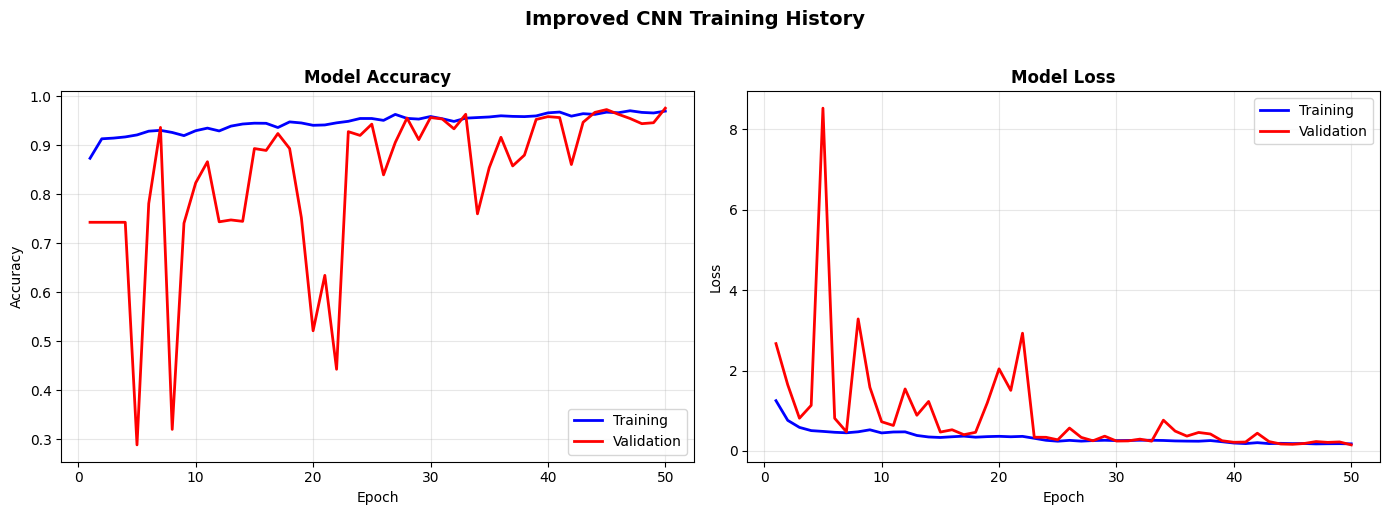

In [16]:
# Save CNN training history
cnn_history_dict = cnn_history.history
with open(CNN_RESULTS_DIR / 'training_history.json', 'w') as f:
    json.dump({k: [float(v) for v in vals] for k, vals in cnn_history_dict.items()}, f, indent=2)

# Plot training history
plot_training_history(
    cnn_history,
    'Improved CNN Training History',
    save_path=CNN_RESULTS_DIR / 'training_history.png'
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 328ms/step

Improved CNN - Test Set Evaluation
Accuracy:  0.8958 (89.58%)
Precision: 0.8897
Recall:    0.9513
F1 Score:  0.9195
AUC-ROC:   0.9517

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.91      0.80      0.85       234
   PNEUMONIA       0.89      0.95      0.92       390

    accuracy                           0.90       624
   macro avg       0.90      0.88      0.89       624
weighted avg       0.90      0.90      0.89       624

Confusion matrix saved to: ../results/models/cnn_improved/confusion_matrix.png


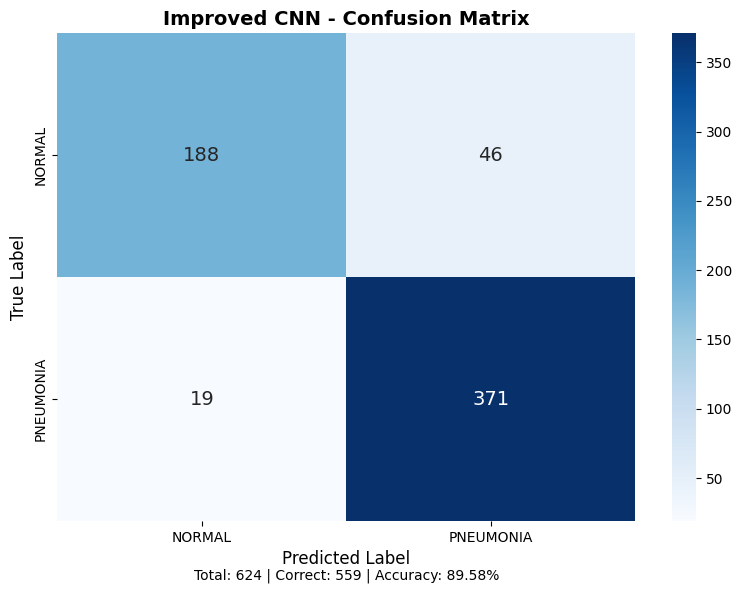

In [17]:
# Evaluate improved CNN on test set
cnn_metrics, cnn_y_true, cnn_y_pred = evaluate_model(
    model_cnn, test_generator, 'Improved CNN'
)

# Plot confusion matrix
plot_confusion_matrix(
    cnn_y_true, cnn_y_pred,
    'Improved CNN - Confusion Matrix',
    save_path=CNN_RESULTS_DIR / 'confusion_matrix.png'
)

In [18]:
# Save CNN model summary and metrics
with open(CNN_RESULTS_DIR / 'model_summary.txt', 'w') as f:
    f.write("IMPROVED CNN - MODEL SUMMARY\n")
    f.write("="*60 + "\n\n")
    model_cnn.summary(print_fn=lambda x: f.write(x + '\n'))
    f.write("\n" + "="*60 + "\n")
    f.write("\nTEST SET METRICS\n")
    f.write("-"*40 + "\n")
    for metric, value in cnn_metrics.items():
        if metric != 'model_name':
            f.write(f"{metric}: {value:.4f}\n")

print(f"\nImproved CNN training complete!")
print(f"Results saved to: {CNN_RESULTS_DIR}")


Improved CNN training complete!
Results saved to: ../results/models/cnn_improved


---
# Part 2: VGG16 with Enhanced Head + Fine-Tuning

Two-phase training approach:
1. **Phase 1**: Train enhanced classification head with frozen VGG16 base
2. **Phase 2**: Fine-tune by unfreezing block5 layers with very low learning rate

In [19]:
def create_vgg16_enhanced(input_shape=(224, 224, 3)):
    """
    Create VGG16 with enhanced classification head.
    
    Enhanced Head:
    - GlobalAveragePooling2D
    - Dense(512) + BatchNormalization + ReLU + Dropout(0.5)
    - Dense(256) + BatchNormalization + ReLU + Dropout(0.3)
    - Dense(1, sigmoid)
    """
    # Load pre-trained VGG16 base
    vgg_base = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    
    # Freeze base model
    vgg_base.trainable = False
    
    # Create enhanced model
    model = Sequential([
        vgg_base,
        GlobalAveragePooling2D(name='gap'),
        Dense(512, name='dense1'),
        BatchNormalization(name='bn1'),
        Activation('relu', name='relu1'),
        Dropout(0.5, name='dropout1'),
        Dense(256, name='dense2'),
        BatchNormalization(name='bn2'),
        Activation('relu', name='relu2'),
        Dropout(0.3, name='dropout2'),
        Dense(1, activation='sigmoid', name='output')
    ], name='VGG16_Enhanced')
    
    return model, vgg_base

# Create VGG16 model
model_vgg16, vgg16_base = create_vgg16_enhanced()
print("VGG16 Enhanced model created!")
print(f"VGG16 base trainable: {vgg16_base.trainable}")
model_vgg16.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
VGG16 Enhanced model created!
VGG16 base trainable: False


Model: "VGG16_Enhanced"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,112,001 (57.65 MB)

 Trainable params: 395,777 (1.51 MB)

 Non-trainable params: 14,716,224 (56.14 MB)

In [20]:
# Phase 1: Compile for training classification head
model_vgg16.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE_TL),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print("VGG16 compiled for Phase 1 (frozen base)")
print(f"  Learning rate: {LEARNING_RATE_TL}")
print(f"  Trainable parameters: {sum([tf.reduce_prod(var.shape).numpy() for var in model_vgg16.trainable_variables]):,}")

VGG16 compiled for Phase 1 (frozen base)
  Learning rate: 0.0001
  Trainable parameters: 395,777


In [21]:
# VGG16 Phase 1 Callbacks
vgg16_callbacks_p1 = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        VGG16_RESULTS_DIR / 'phase1_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

print("VGG16 Phase 1 callbacks configured")

VGG16 Phase 1 callbacks configured


In [22]:
# Phase 1: Train classification head
print("="*60)
print("VGG16 - PHASE 1: TRAINING CLASSIFICATION HEAD")
print("="*60)
print(f"  Epochs: {EPOCHS_PHASE1}")
print(f"  Learning rate: {LEARNING_RATE_TL}")
print(f"  VGG16 base frozen: True")
print("="*60)

vgg16_history_p1 = model_vgg16.fit(
    train_generator,
    epochs=EPOCHS_PHASE1,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=vgg16_callbacks_p1,
    verbose=1
)

phase1_epochs = len(vgg16_history_p1.history['accuracy'])
print(f"\nPhase 1 completed after {phase1_epochs} epochs")

VGG16 - PHASE 1: TRAINING CLASSIFICATION HEAD
  Epochs: 15
  Learning rate: 0.0001
  VGG16 base frozen: True
Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5484 - loss: 0.6658 - precision_1: 0.9329 - recall_1: 0.4060
Epoch 1: val_loss improved from None to 0.58925, saving model to ../results/models/vgg16_improved/phase1_model.keras

Epoch 1: finished saving model to ../results/models/vgg16_improved/phase1_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 343s 3s/step - accuracy: 0.6777 - loss: 0.5165 - precision_1: 0.9803 - recall_1: 0.5777 - val_accuracy: 0.8408 - val_loss: 0.5892 - val_precision_1: 0.9951 - val_recall_1: 0.7897 - learning_rate: 1.0000e-04
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8456 - loss: 0.3204 - precision_1: 0.9776 - recall_1: 0.8109
Epoch 2: val_loss improved from 0.58925 to 0.46387, saving model to ../results/models/vgg16_improved/phase1_model.keras

Epoch 2: finished saving model to ../results/models/vgg16_improved/phase1_mode

In [23]:
# Phase 2: Unfreeze block5 for fine-tuning
print("="*60)
print("VGG16 - PHASE 2: FINE-TUNING (UNFREEZING BLOCK5)")
print("="*60)

# Unfreeze the base model
vgg16_base.trainable = True

# Freeze all layers except block5
# VGG16 layer names: block1_conv1, block1_conv2, block1_pool, block2_conv1, ...
for layer in vgg16_base.layers:
    if 'block5' not in layer.name:
        layer.trainable = False
    else:
        layer.trainable = True
        print(f"  Unfrozen: {layer.name}")

# Count trainable parameters
trainable_count = sum([tf.reduce_prod(var.shape).numpy() for var in model_vgg16.trainable_variables])
print(f"\nTotal trainable parameters: {trainable_count:,}")

VGG16 - PHASE 2: FINE-TUNING (UNFREEZING BLOCK5)
  Unfrozen: block5_conv1
  Unfrozen: block5_conv2
  Unfrozen: block5_conv3
  Unfrozen: block5_pool

Total trainable parameters: 7,475,201


In [24]:
# Recompile with lower learning rate for fine-tuning
model_vgg16.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE_FT),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print(f"VGG16 recompiled for Phase 2")
print(f"  Learning rate: {LEARNING_RATE_FT}")

VGG16 recompiled for Phase 2
  Learning rate: 1e-05


In [25]:
# VGG16 Phase 2 Callbacks
vgg16_callbacks_p2 = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        VGG16_RESULTS_DIR / 'finetuned_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-8,
        verbose=1
    )
]

print("VGG16 Phase 2 callbacks configured")

VGG16 Phase 2 callbacks configured


In [26]:
# Phase 2: Fine-tune
print("="*60)
print(f"Starting fine-tuning for {EPOCHS_PHASE2} epochs...")
print("="*60)

vgg16_history_p2 = model_vgg16.fit(
    train_generator,
    epochs=EPOCHS_PHASE2,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=vgg16_callbacks_p2,
    verbose=1
)

phase2_epochs = len(vgg16_history_p2.history['accuracy'])
print(f"\nPhase 2 completed after {phase2_epochs} epochs")
print(f"Total training: {phase1_epochs + phase2_epochs} epochs")

Starting fine-tuning for 20 epochs...
Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9442 - loss: 0.1437 - precision_2: 0.9888 - recall_2: 0.9359
Epoch 1: val_loss improved from None to 0.22728, saving model to ../results/models/vgg16_improved/finetuned_model.keras

Epoch 1: finished saving model to ../results/models/vgg16_improved/finetuned_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 368s 3s/step - accuracy: 0.9415 - loss: 0.1577 - precision_2: 0.9854 - recall_2: 0.9352 - val_accuracy: 0.9118 - val_loss: 0.2273 - val_precision_2: 0.9985 - val_recall_2: 0.8826 - learning_rate: 1.0000e-05
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9544 - loss: 0.1253 - precision_2: 0.9866 - recall_2: 0.9512
Epoch 2: val_loss improved from 0.22728 to 0.13739, saving model to ../results/models/vgg16_improved/finetuned_model.keras

Epoch 2: finished saving model to ../results/models/vgg16_improved/finetuned_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 388s 3s/step - accurac

In [ ]:
from tensorflow.keras.models import load_model

model_vgg16 = load_model(VGG16_RESULTS_DIR / 'finetuned_model.keras')
print("Loaded fine-tuned VGG16 model")

# Plot Phase 2 history only (Phase 1 history was lost)
vgg16_history_dict = vgg16_history_p2.history

  # Save Phase 2 history
with open(VGG16_RESULTS_DIR / 'training_history.json', 'w') as f:
    json.dump({k: [float(v) for v in vals] for k, vals in vgg16_history_dict.items()}, f, indent=2)

  # Plot Phase 2 only
plot_training_history(
    vgg16_history_p2,
    'VGG16 Enhanced - Training History (Phase 2: Fine-Tuning)',
    save_path=VGG16_RESULTS_DIR / 'training_history.png'
)

phase1_epochs = 0  # Set to 0 since we don't have Phase 1 data
phase2_epochs = len(vgg16_history_p2.history['accuracy'])
print(f"Phase 2 completed: {phase2_epochs} epochs")

FileNotFoundError: [Errno 2] No such file or directory: '../results/models/vgg16_improved/training_history.json'

In [13]:
# Combine histories and plot
vgg16_combined_history = combine_histories(vgg16_history_p1, vgg16_history_p2)

# Save combined history
with open(VGG16_RESULTS_DIR / 'training_history.json', 'w') as f:
    json.dump({k: [float(v) for v in vals] for k, vals in vgg16_combined_history.items()}, f, indent=2)

# Plot with phase marker
plot_training_history(
    vgg16_combined_history,
    'VGG16 Enhanced - Training History (Phase 1 + Fine-Tuning)',
    save_path=VGG16_RESULTS_DIR / 'training_history.png',
    phase2_start=phase1_epochs
)

NameError: name 'vgg16_history_p1' is not defined

20/20 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step

VGG16 Enhanced (Fine-tuned) - Test Set Evaluation
Accuracy:  0.8894 (88.94%)
Precision: 0.8575
Recall:    0.9872
F1 Score:  0.9178
AUC-ROC:   0.9584

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.97      0.73      0.83       234
   PNEUMONIA       0.86      0.99      0.92       390

    accuracy                           0.89       624
   macro avg       0.91      0.86      0.87       624
weighted avg       0.90      0.89      0.89       624

Confusion matrix saved to: ../results/models/vgg16_improved/confusion_matrix.png


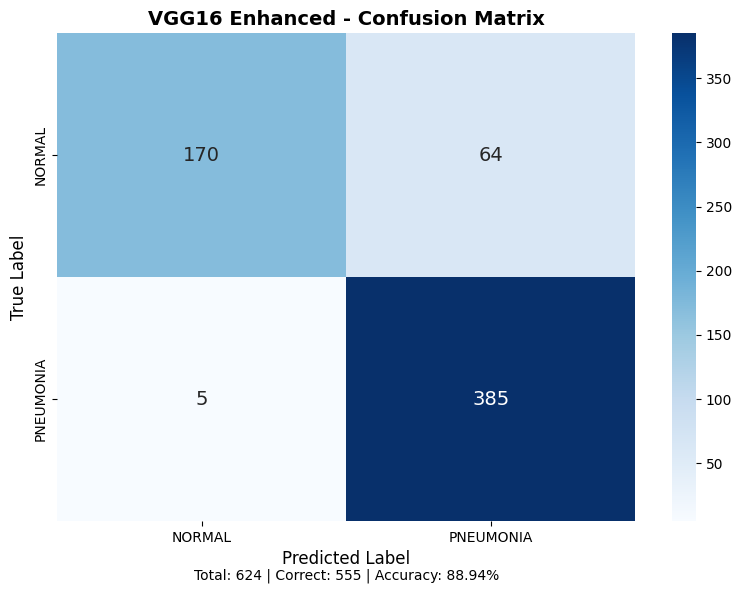

In [17]:
# Evaluate VGG16 on test set
vgg16_metrics, vgg16_y_true, vgg16_y_pred = evaluate_model(
    model_vgg16, test_generator, 'VGG16 Enhanced (Fine-tuned)'
)

# Plot confusion matrix
plot_confusion_matrix(
    vgg16_y_true, vgg16_y_pred,
    'VGG16 Enhanced - Confusion Matrix',
    save_path=VGG16_RESULTS_DIR / 'confusion_matrix.png'
)

In [18]:
# Save VGG16 summary and metrics
with open(VGG16_RESULTS_DIR / 'model_summary.txt', 'w') as f:
    f.write("VGG16 ENHANCED - MODEL SUMMARY\n")
    f.write("="*60 + "\n\n")
    f.write("Training Approach: Two-Phase\n")
    f.write(f"  Phase 1: {phase1_epochs} epochs (frozen base, LR={LEARNING_RATE_TL})\n")
    f.write(f"  Phase 2: {phase2_epochs} epochs (block5 unfrozen, LR={LEARNING_RATE_FT})\n")
    f.write(f"  Total: {phase1_epochs + phase2_epochs} epochs\n\n")
    model_vgg16.summary(print_fn=lambda x: f.write(x + '\n'))
    f.write("\n" + "="*60 + "\n")
    f.write("\nTEST SET METRICS\n")
    f.write("-"*40 + "\n")
    for metric, value in vgg16_metrics.items():
        if metric != 'model_name':
            f.write(f"{metric}: {value:.4f}\n")

print(f"\nVGG16 Enhanced training complete!")
print(f"Results saved to: {VGG16_RESULTS_DIR}")

NameError: name 'phase1_epochs' is not defined

---
# Part 3: ResNet50 with Enhanced Head + Fine-Tuning

Two-phase training approach:
1. **Phase 1**: Train enhanced classification head with frozen ResNet50 base
2. **Phase 2**: Fine-tune by unfreezing conv5 block with very low learning rate

In [19]:
def create_resnet50_enhanced(input_shape=(224, 224, 3)):
    """
    Create ResNet50 with enhanced classification head.
    
    Enhanced Head:
    - GlobalAveragePooling2D
    - Dense(512) + BatchNormalization + ReLU + Dropout(0.5)
    - Dense(256) + BatchNormalization + ReLU + Dropout(0.3)
    - Dense(1, sigmoid)
    """
    # Load pre-trained ResNet50 base
    resnet_base = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    
    # Freeze base model
    resnet_base.trainable = False
    
    # Create enhanced model
    model = Sequential([
        resnet_base,
        GlobalAveragePooling2D(name='gap'),
        Dense(512, name='dense1'),
        BatchNormalization(name='bn1'),
        Activation('relu', name='relu1'),
        Dropout(0.5, name='dropout1'),
        Dense(256, name='dense2'),
        BatchNormalization(name='bn2'),
        Activation('relu', name='relu2'),
        Dropout(0.3, name='dropout2'),
        Dense(1, activation='sigmoid', name='output')
    ], name='ResNet50_Enhanced')
    
    return model, resnet_base

# Create ResNet50 model
model_resnet50, resnet50_base = create_resnet50_enhanced()
print("ResNet50 Enhanced model created!")
print(f"ResNet50 base trainable: {resnet50_base.trainable}")
model_resnet50.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
ResNet50 Enhanced model created!
ResNet50 base trainable: False


Model: "ResNet50_Enhanced"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,771,457 (94.50 MB)

 Trainable params: 1,182,209 (4.51 MB)

 Non-trainable params: 23,589,248 (89.99 MB)

In [20]:
# Phase 1: Compile for training classification head
model_resnet50.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE_TL),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print("ResNet50 compiled for Phase 1 (frozen base)")
print(f"  Learning rate: {LEARNING_RATE_TL}")
print(f"  Trainable parameters: {sum([tf.reduce_prod(var.shape).numpy() for var in model_resnet50.trainable_variables]):,}")

ResNet50 compiled for Phase 1 (frozen base)
  Learning rate: 0.0001
  Trainable parameters: 1,182,209


In [21]:
# ResNet50 Phase 1 Callbacks
resnet_callbacks_p1 = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        RESNET_RESULTS_DIR / 'phase1_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

print("ResNet50 Phase 1 callbacks configured")

ResNet50 Phase 1 callbacks configured


In [22]:
# Phase 1: Train classification head
print("="*60)
print("RESNET50 - PHASE 1: TRAINING CLASSIFICATION HEAD")
print("="*60)
print(f"  Epochs: {EPOCHS_PHASE1}")
print(f"  Learning rate: {LEARNING_RATE_TL}")
print(f"  ResNet50 base frozen: True")
print("="*60)

resnet_history_p1 = model_resnet50.fit(
    train_generator,
    epochs=EPOCHS_PHASE1,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=resnet_callbacks_p1,
    verbose=1
)

resnet_phase1_epochs = len(resnet_history_p1.history['accuracy'])
print(f"\nPhase 1 completed after {resnet_phase1_epochs} epochs")

RESNET50 - PHASE 1: TRAINING CLASSIFICATION HEAD
  Epochs: 15
  Learning rate: 0.0001
  ResNet50 base frozen: True
Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 598ms/step - accuracy: 0.7250 - loss: 0.5615 - precision: 0.8844 - recall: 0.7276
Epoch 1: val_loss improved from None to 0.64323, saving model to ../results/models/resnet50_improved/phase1_model.keras

Epoch 1: finished saving model to ../results/models/resnet50_improved/phase1_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 103s 758ms/step - accuracy: 0.7704 - loss: 0.4705 - precision: 0.9270 - recall: 0.7500 - val_accuracy: 0.8063 - val_loss: 0.6432 - val_precision: 0.8716 - val_recall: 0.8671 - learning_rate: 1.0000e-04
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 602ms/step - accuracy: 0.8280 - loss: 0.3886 - precision: 0.9544 - recall: 0.8025
Epoch 2: val_loss improved from 0.64323 to 0.58006, saving model to ../results/models/resnet50_improved/phase1_model.keras

Epoch 2: finished saving model to ../results/models/resnet50_improved/

In [23]:
# Phase 2: Unfreeze conv5 block for fine-tuning
print("="*60)
print("RESNET50 - PHASE 2: FINE-TUNING (UNFREEZING CONV5 BLOCK)")
print("="*60)

# Unfreeze the base model
resnet50_base.trainable = True

# Freeze all layers except conv5 block
# ResNet50 layer names: conv5_block1_*, conv5_block2_*, conv5_block3_*
unfrozen_layers = 0
for layer in resnet50_base.layers:
    if 'conv5' not in layer.name:
        layer.trainable = False
    else:
        layer.trainable = True
        unfrozen_layers += 1

print(f"  Unfrozen {unfrozen_layers} layers in conv5 block")

# Count trainable parameters
trainable_count = sum([tf.reduce_prod(var.shape).numpy() for var in model_resnet50.trainable_variables])
print(f"  Total trainable parameters: {trainable_count:,}")

RESNET50 - PHASE 2: FINE-TUNING (UNFREEZING CONV5 BLOCK)
  Unfrozen 32 layers in conv5 block
  Total trainable parameters: 16,158,209


In [24]:
# Recompile with lower learning rate for fine-tuning
model_resnet50.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE_FT),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print(f"ResNet50 recompiled for Phase 2")
print(f"  Learning rate: {LEARNING_RATE_FT}")

ResNet50 recompiled for Phase 2
  Learning rate: 1e-05


In [25]:
# ResNet50 Phase 2 Callbacks
resnet_callbacks_p2 = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        RESNET_RESULTS_DIR / 'finetuned_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-8,
        verbose=1
    )
]

print("ResNet50 Phase 2 callbacks configured")

ResNet50 Phase 2 callbacks configured


In [26]:
# Phase 2: Fine-tune
print("="*60)
print(f"Starting fine-tuning for {EPOCHS_PHASE2} epochs...")
print("="*60)

resnet_history_p2 = model_resnet50.fit(
    train_generator,
    epochs=EPOCHS_PHASE2,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=resnet_callbacks_p2,
    verbose=1
)

resnet_phase2_epochs = len(resnet_history_p2.history['accuracy'])
print(f"\nPhase 2 completed after {resnet_phase2_epochs} epochs")
print(f"Total training: {resnet_phase1_epochs + resnet_phase2_epochs} epochs")

Starting fine-tuning for 20 epochs...
Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 918ms/step - accuracy: 0.8388 - loss: 0.4289 - precision_1: 0.9202 - recall_1: 0.8580
Epoch 1: val_loss improved from None to 0.94026, saving model to ../results/models/resnet50_improved/finetuned_model.keras

Epoch 1: finished saving model to ../results/models/resnet50_improved/finetuned_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.8663 - loss: 0.3251 - precision_1: 0.9504 - recall_1: 0.8652 - val_accuracy: 0.7430 - val_loss: 0.9403 - val_precision_1: 0.7430 - val_recall_1: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 919ms/step - accuracy: 0.8914 - loss: 0.2430 - precision_1: 0.9709 - recall_1: 0.8792
Epoch 2: val_loss improved from 0.94026 to 0.40571, saving model to ../results/models/resnet50_improved/finetuned_model.keras

Epoch 2: finished saving model to ../results/models/resnet50_improved/finetuned_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 140s

In [38]:
# Combine histories and plot
resnet_combined_history = combine_histories(resnet_history_p1, resnet_history_p2)

# Save combined history
with open(RESNET_RESULTS_DIR / 'training_history.json', 'w') as f:
    json.dump({k: [float(v) for v in vals] for k, vals in resnet_combined_history.items()}, f, indent=2)

# Plot with phase marker
plot_training_history(
    resnet_combined_history,
    'ResNet50 Enhanced - Training History (Phase 1 + Fine-Tuning)',
    save_path=RESNET_RESULTS_DIR / 'training_history.png',
    phase2_start=resnet_phase1_epochs
)

KeyError: 'precision'

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 600ms/step

ResNet50 Enhanced (Fine-tuned) - Test Set Evaluation
Accuracy:  0.8734 (87.34%)
Precision: 0.8642
Recall:    0.9462
F1 Score:  0.9033
AUC-ROC:   0.9385

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.89      0.75      0.82       234
   PNEUMONIA       0.86      0.95      0.90       390

    accuracy                           0.87       624
   macro avg       0.88      0.85      0.86       624
weighted avg       0.88      0.87      0.87       624

Confusion matrix saved to: ../results/models/resnet50_improved/confusion_matrix.png


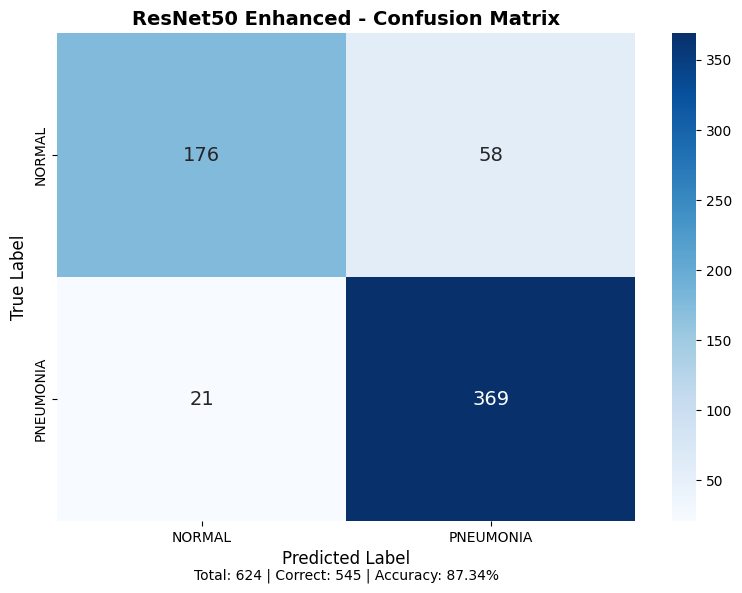

In [29]:
# Evaluate ResNet50 on test set
resnet_metrics, resnet_y_true, resnet_y_pred = evaluate_model(
    model_resnet50, test_generator, 'ResNet50 Enhanced (Fine-tuned)'
)

# Plot confusion matrix
plot_confusion_matrix(
    resnet_y_true, resnet_y_pred,
    'ResNet50 Enhanced - Confusion Matrix',
    save_path=RESNET_RESULTS_DIR / 'confusion_matrix.png'
)

In [30]:
# Save ResNet50 summary and metrics
with open(RESNET_RESULTS_DIR / 'model_summary.txt', 'w') as f:
    f.write("RESNET50 ENHANCED - MODEL SUMMARY\n")
    f.write("="*60 + "\n\n")
    f.write("Training Approach: Two-Phase\n")
    f.write(f"  Phase 1: {resnet_phase1_epochs} epochs (frozen base, LR={LEARNING_RATE_TL})\n")
    f.write(f"  Phase 2: {resnet_phase2_epochs} epochs (conv5 unfrozen, LR={LEARNING_RATE_FT})\n")
    f.write(f"  Total: {resnet_phase1_epochs + resnet_phase2_epochs} epochs\n\n")
    model_resnet50.summary(print_fn=lambda x: f.write(x + '\n'))
    f.write("\n" + "="*60 + "\n")
    f.write("\nTEST SET METRICS\n")
    f.write("-"*40 + "\n")
    for metric, value in resnet_metrics.items():
        if metric != 'model_name':
            f.write(f"{metric}: {value:.4f}\n")

print(f"\nResNet50 Enhanced training complete!")
print(f"Results saved to: {RESNET_RESULTS_DIR}")


ResNet50 Enhanced training complete!
Results saved to: ../results/models/resnet50_improved


---
# Part 4: Model Comparison and Summary

In [41]:
# Create comparison dataframe
all_metrics = [cnn_metrics, vgg16_metrics, resnet_metrics]
comparison_df = pd.DataFrame(all_metrics)
comparison_df = comparison_df.set_index('model_name')

# Display comparison table
print("="*70)
print("MODEL COMPARISON - TEST SET METRICS")
print("="*70)
print(comparison_df.round(4).to_string())
print("="*70)

MODEL COMPARISON - TEST SET METRICS
                                accuracy  precision  recall      f1  auc_roc
model_name                                                                  
Improved CNN                      0.8958     0.8897  0.9513  0.9195   0.9517
VGG16 Enhanced (Fine-tuned)       0.8894     0.8575  0.9872  0.9178   0.9584
ResNet50 Enhanced (Fine-tuned)    0.8734     0.8642  0.9462  0.9033   0.9385


Comparison plot saved to: ../results/models/model_comparison.png


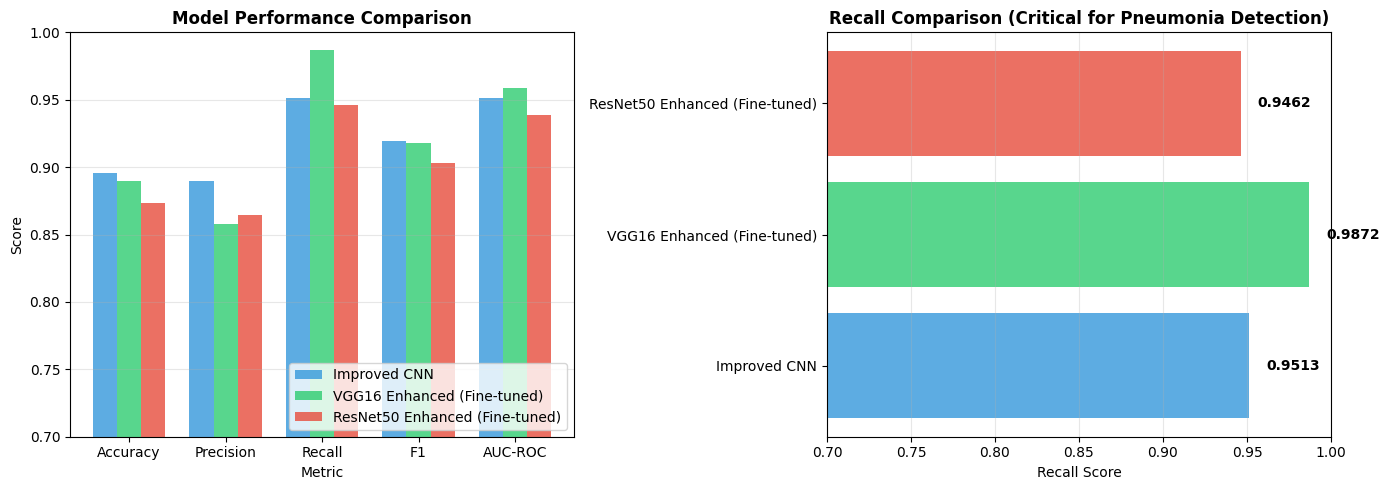

In [42]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Metrics bar plot
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'auc_roc']
x = np.arange(len(metrics_to_plot))
width = 0.25

models = comparison_df.index.tolist()
colors = ['#3498db', '#2ecc71', '#e74c3c']

for i, model in enumerate(models):
    values = [comparison_df.loc[model, m] for m in metrics_to_plot]
    axes[0].bar(x + i*width, values, width, label=model, color=colors[i], alpha=0.8)

axes[0].set_xlabel('Metric')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison', fontweight='bold')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC'])
axes[0].legend(loc='lower right')
axes[0].set_ylim([0.7, 1.0])
axes[0].grid(axis='y', alpha=0.3)

# Recall comparison (important for pneumonia detection)
recall_values = [comparison_df.loc[m, 'recall'] for m in models]
bars = axes[1].barh(models, recall_values, color=colors, alpha=0.8)
axes[1].set_xlabel('Recall Score')
axes[1].set_title('Recall Comparison (Critical for Pneumonia Detection)', fontweight='bold')
axes[1].set_xlim([0.7, 1.0])
axes[1].grid(axis='x', alpha=0.3)

# Add value labels
for bar, val in zip(bars, recall_values):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{val:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_BASE / 'model_comparison.png', dpi=150, bbox_inches='tight')
print(f"Comparison plot saved to: {RESULTS_BASE / 'model_comparison.png'}")
plt.show()

In [43]:
# Save comparison summary
with open(RESULTS_BASE / 'model_comparison.txt', 'w') as f:
    f.write("IMPROVED MODELS - COMPARISON SUMMARY\n")
    f.write("="*70 + "\n")
    f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
    
    f.write("MODEL ARCHITECTURES\n")
    f.write("-"*70 + "\n")
    f.write("1. Improved CNN:\n")
    f.write("   - 3 conv blocks with BatchNormalization (32→64→128 filters)\n")
    f.write("   - Double conv layers per block, progressive dropout (0.25→0.5)\n")
    f.write("   - Dense(256) with L2 regularization + BatchNorm\n\n")
    f.write("2. VGG16 Enhanced:\n")
    f.write("   - Pre-trained VGG16 base + enhanced classification head\n")
    f.write("   - Head: GAP → Dense(512)+BN+Dropout(0.5) → Dense(256)+BN+Dropout(0.3) → Output\n")
    f.write("   - Two-phase training: frozen base → fine-tuning block5\n\n")
    f.write("3. ResNet50 Enhanced:\n")
    f.write("   - Pre-trained ResNet50 base + enhanced classification head\n")
    f.write("   - Head: GAP → Dense(512)+BN+Dropout(0.5) → Dense(256)+BN+Dropout(0.3) → Output\n")
    f.write("   - Two-phase training: frozen base → fine-tuning conv5 block\n\n")
    
    f.write("TEST SET METRICS\n")
    f.write("-"*70 + "\n")
    f.write(comparison_df.round(4).to_string())
    f.write("\n\n")
    
    # Find best model for each metric
    f.write("BEST MODEL PER METRIC\n")
    f.write("-"*70 + "\n")
    for metric in metrics_to_plot:
        best_model = comparison_df[metric].idxmax()
        best_value = comparison_df[metric].max()
        f.write(f"{metric.upper():12s}: {best_model} ({best_value:.4f})\n")

print(f"Comparison summary saved to: {RESULTS_BASE / 'model_comparison.txt'}")

Comparison summary saved to: ../results/models/model_comparison.txt


In [44]:
# Final summary
print("\n" + "="*70)
print("TRAINING COMPLETE - SUMMARY")
print("="*70)
print("\nModels trained:")
print(f"  1. Improved CNN: {CNN_RESULTS_DIR}")
print(f"  2. VGG16 Enhanced: {VGG16_RESULTS_DIR}")
print(f"  3. ResNet50 Enhanced: {RESNET_RESULTS_DIR}")

print("\nBest performing models:")
for metric in ['accuracy', 'recall', 'f1']:
    best = comparison_df[metric].idxmax()
    val = comparison_df[metric].max()
    print(f"  {metric.upper():10s}: {best} ({val:.4f})")

print("\nNote: For pneumonia detection, RECALL is the most important metric")
print("      (minimizing false negatives is critical for patient safety)")
print("="*70)


TRAINING COMPLETE - SUMMARY

Models trained:
  1. Improved CNN: ../results/models/cnn_improved
  2. VGG16 Enhanced: ../results/models/vgg16_improved
  3. ResNet50 Enhanced: ../results/models/resnet50_improved

Best performing models:
  ACCURACY  : Improved CNN (0.8958)
  RECALL    : VGG16 Enhanced (Fine-tuned) (0.9872)
  F1        : Improved CNN (0.9195)

Note: For pneumonia detection, RECALL is the most important metric
      (minimizing false negatives is critical for patient safety)


In [45]:
# DIAGNOSTIC: Check what's in memory
print("="*60)
print("DIAGNOSTIC: Checking what's available")
print("="*60)

  # Check models
print("\n📦 MODELS:")
for name in ['model_cnn', 'model_vgg16', 'model_resnet50']:
    try:
        model = eval(name)
        print(f"  ✓ {name} - EXISTS (trained weights in memory)")
    except NameError:
        print(f"  ✗ {name} - MISSING")

  # Check metrics
print("\n📊 METRICS:")
for name in ['cnn_metrics', 'vgg16_metrics', 'resnet_metrics']:
    try:
        m = eval(name)
        print(f"  ✓ {name} - EXISTS")
    except NameError:
        print(f"  ✗ {name} - MISSING")

  # Check histories
print("\n📈 HISTORIES:")
for name in ['cnn_history', 'vgg16_history_p1', 'vgg16_history_p2', 'resnet_history_p1', 'resnet_history_p2']:
    try:
        h = eval(name)
        print(f"  ✓ {name} - EXISTS")
    except NameError:
        print(f"  ✗ {name} - MISSING")

  # Check data generators
print("\n🗂️ DATA GENERATORS:")
for name in ['train_generator', 'val_generator', 'test_generator']:
    try:
        g = eval(name)
        print(f"  ✓ {name} - EXISTS")
    except NameError:
        print(f"  ✗ {name} - MISSING")

print("\n" + "="*60)

DIAGNOSTIC: Checking what's available

📦 MODELS:
  ✓ model_cnn - EXISTS (trained weights in memory)
  ✓ model_vgg16 - EXISTS (trained weights in memory)
  ✓ model_resnet50 - EXISTS (trained weights in memory)

📊 METRICS:
  ✓ cnn_metrics - EXISTS
  ✓ vgg16_metrics - EXISTS
  ✓ resnet_metrics - EXISTS

📈 HISTORIES:
  ✗ cnn_history - MISSING
  ✗ vgg16_history_p1 - MISSING
  ✗ vgg16_history_p2 - MISSING
  ✓ resnet_history_p1 - EXISTS
  ✓ resnet_history_p2 - EXISTS

🗂️ DATA GENERATORS:
  ✓ train_generator - EXISTS
  ✓ val_generator - EXISTS
  ✓ test_generator - EXISTS



In [34]:
from pathlib import Path
import os

print("="*60)
print("CHECKING SAVED FILES ON DISK")
print("="*60)

RESULTS_BASE = Path('../results/models')

for folder in ['cnn_improved', 'vgg16_improved', 'resnet50_improved', 'baseline_cnn']:
    path = RESULTS_BASE / folder
    if path.exists():
        print(f"\n📁 {folder}/")
        for f in sorted(path.iterdir()):
            size = f.stat().st_size / 1024  # KB
            if size > 1024:
                size_str = f"{size/1024:.1f} MB"
            else:
                size_str = f"{size:.1f} KB"
            print(f"   {f.name:40s} {size_str}")
    else:
        print(f"\n {folder}/ - NOT FOUND")

CHECKING SAVED FILES ON DISK

📁 cnn_improved/
   best_model.keras                         297.4 MB
   confusion_matrix.png                     46.5 KB
   model_summary.txt                        10.2 KB
   training_history.json                    10.7 KB
   training_history.png                     101.2 KB

📁 vgg16_improved/
   confusion_matrix.png                     46.6 KB
   finetuned_model.keras                    114.8 MB
   model_summary.txt                        0.1 KB
   phase1_model.keras                       60.8 MB

📁 resnet50_improved/
   confusion_matrix.png                     48.3 KB
   finetuned_model.keras                    218.5 MB
   model_summary.txt                        4.5 KB
   phase1_model.keras                       104.2 MB

📁 baseline_cnn/
   best_model.h5                            148.1 MB
   confusion_matrix.png                     164.2 KB
   final_model.h5                           148.1 MB
   metrics.txt                              0.6 KB
   mode

In [36]:
from tensorflow.keras.models import load_model

# Load the improved CNN that was trained earlier
model_cnn = load_model(Path('../results/models/cnn_improved/best_model.keras'))
print("✓ Improved CNN loaded from disk")

  # Evaluate it
def evaluate_model(model, generator, model_name):
    generator.reset()
    y_pred_proba = model.predict(generator, verbose=1)
    y_pred = (y_pred_proba > 0.5).astype(int).flatten()
    y_true = generator.classes

    return {
        'model_name': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'auc_roc': roc_auc_score(y_true, y_pred_proba)
    }

cnn_metrics = evaluate_model(model_cnn, test_generator, 'Improved CNN')
print(f"\n✓ CNN Accuracy: {cnn_metrics['accuracy']:.4f}")

✓ Improved CNN loaded from disk
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 318ms/step

✓ CNN Accuracy: 0.8958


In [37]:
all_metrics = [cnn_metrics, vgg16_metrics, resnet_metrics]
comparison_df = pd.DataFrame(all_metrics).set_index('model_name')

print("="*70)
print("MODEL COMPARISON - TEST SET METRICS")
print("="*70)
print(comparison_df.round(4).to_string())
print("="*70)

MODEL COMPARISON - TEST SET METRICS
                                accuracy  precision  recall      f1  auc_roc
model_name                                                                  
Improved CNN                      0.8958     0.8897  0.9513  0.9195   0.9517
VGG16 Enhanced (Fine-tuned)       0.8894     0.8575  0.9872  0.9178   0.9584
ResNet50 Enhanced (Fine-tuned)    0.8734     0.8642  0.9462  0.9033   0.9385
